In [1]:
import math 
def utilization(arrival_rate, service_rate, servers):
    rho = arrival_rate / (servers * service_rate)
    return rho


def calculate_p0(arrival_rate, service_rate, servers):               #system is empty!
    rho = utilization(arrival_rate, service_rate, servers)

    sum_terms = 0
    for n in range(servers):
        sum_terms += (arrival_rate / service_rate) ** n / math.factorial(n)

    last_term = ((arrival_rate / service_rate) ** servers) / (
        math.factorial(servers) * (1 - rho)
    )

    p0 = 1 / (sum_terms + last_term)
    return p0


def calculate_lq(arrival_rate, service_rate, servers):
    rho = utilization(arrival_rate, service_rate, servers)
    p0 = calculate_p0(arrival_rate, service_rate, servers)

    numerator = p0 * ((arrival_rate / service_rate) ** servers) * rho
    denominator = math.factorial(servers) * ((1 - rho) ** 2)

    lq = numerator / denominator
    return lq


def calculate_wq(arrival_rate, service_rate, servers):
    lq = calculate_lq(arrival_rate, service_rate, servers)
    wq = lq / arrival_rate
    return wq


def calculate_l(arrival_rate, service_rate, servers):
    lq = calculate_lq(arrival_rate, service_rate, servers)
    l = lq + (arrival_rate / service_rate)
    return l


def calculate_w(arrival_rate, service_rate, servers):
    wq = calculate_wq(arrival_rate, service_rate, servers)
    w = wq + (1 / service_rate)
    return w

In [1]:
arrival_rate = 10      # customers per hour
service_rate = 120      # customers per hour per barista
servers = 3            # baristas

print("Queueing Model Results (M/M/c)")
print("------------------------------")

print("Arrival Rate (λ)", arrival_rate)
print("Service Rate (μ)",service_rate)
print("Number of Baristas (c)", servers)
print()
print("Utilization:", utilization(arrival_rate, service_rate, servers))
print("P0:", calculate_p0(arrival_rate, service_rate, servers))
print("Lq:", calculate_lq(arrival_rate, service_rate, servers))
print("Wq:", calculate_wq(arrival_rate, service_rate, servers))
print("L:", calculate_l(arrival_rate, service_rate, servers))
print("W:", calculate_w(arrival_rate, service_rate, servers))


Queueing Model Results (M/M/c)
------------------------------
Arrival Rate (λ) 10
Service Rate (μ) 120
Number of Baristas (c) 3



NameError: name 'utilization' is not defined

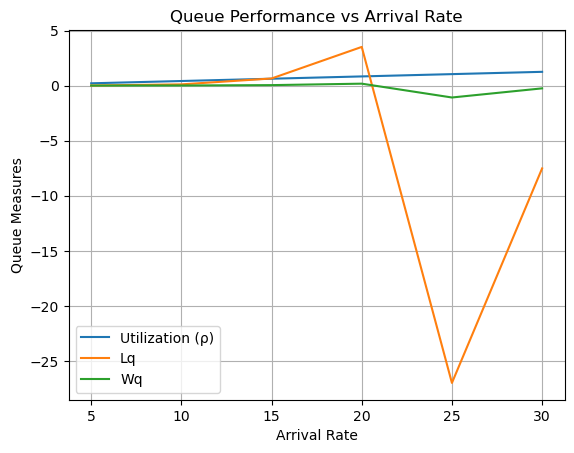

In [3]:
import matplotlib.pyplot as plt

arrival_rates = [5, 10, 15, 20, 25, 30]

util = []
lq = []
wq = []

for a in arrival_rates:
    util.append(utilization(a, service_rate, servers))
    lq.append(calculate_lq(a, service_rate, servers))
    wq.append(calculate_wq(a, service_rate, servers))

plt.figure()
plt.plot(arrival_rates, util, label="Utilization (ρ)")
plt.plot(arrival_rates, lq, label="Lq")
plt.plot(arrival_rates, wq, label="Wq")

plt.xlabel("Arrival Rate")
plt.ylabel("Queue Measures")
plt.title("Queue Performance vs Arrival Rate")
plt.legend()
plt.grid(True)
plt.show()
